In [2]:
from tensorflow.keras.datasets import imdb

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training Reviews :", len(X_train))
print("Testing Reviews  :", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Reviews : 25000
Testing Reviews  : 25000


In [5]:
total_reviews = len(X_train) + len(X_test)

print("Total Reviews:", total_reviews)

Total Reviews: 50000


In [6]:
positive_reviews = np.sum(y_train) + np.sum(y_test)

print("Positive Reviews:", positive_reviews)

Positive Reviews: 25000


In [7]:
negative_reviews = total_reviews - positive_reviews

print("Negative Reviews:", negative_reviews)

Negative Reviews: 25000


In [8]:
sentiment_df = pd.DataFrame({

    "Sentiment":["Positive","Negative"],

    "Count":[
        positive_reviews,
        negative_reviews
    ]
})

sentiment_df

,Sentiment,Count
0,Positive,25000
1,Negative,25000


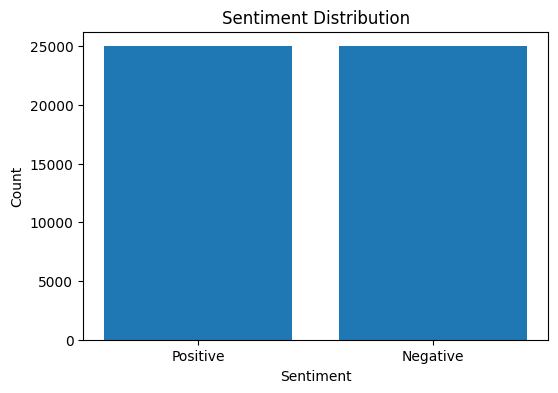

In [9]:
plt.figure(figsize=(6,4))

plt.bar(
    sentiment_df["Sentiment"],
    sentiment_df["Count"]
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [10]:
review_lengths = [

    len(review)

    for review in X_train
]

In [11]:
avg_length = np.mean(
    review_lengths
)

print(
    "Average Review Length:",
    round(avg_length,2)
)

Average Review Length: 238.71


In [12]:
longest_review = max(
    review_lengths
)

print(
    "Longest Review Length:",
    longest_review
)

Longest Review Length: 2494


In [13]:
shortest_review = min(
    review_lengths
)

print(
    "Shortest Review Length:",
    shortest_review
)

Shortest Review Length: 11


In [14]:
review_stats = pd.DataFrame({

    "Metric":[
        "Average Length",
        "Longest Review",
        "Shortest Review"
    ],

    "Value":[
        round(avg_length,2),
        longest_review,
        shortest_review
    ]
})

review_stats

,Metric,Value
0,Average Length,238.71
1,Longest Review,2494.00
2,Shortest Review,11.00


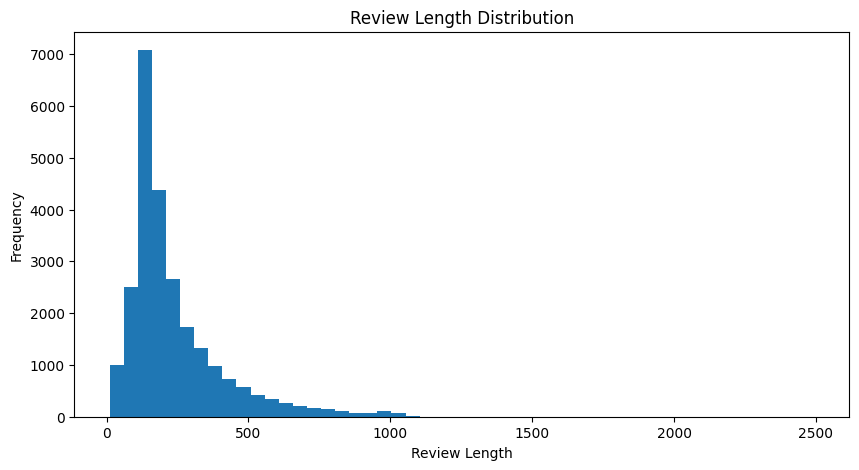

In [15]:
plt.figure(figsize=(10,5))

plt.hist(
    review_lengths,
    bins=50
)

plt.title(
    "Review Length Distribution"
)

plt.xlabel(
    "Review Length"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [16]:
word_index = imdb.get_word_index()

reverse_word_index = {

    value:key

    for key,value in word_index.items()
}

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
decoded_review = " ".join(

    [
        reverse_word_index.get(
            i-3,
            "?"
        )

        for i in X_train[0]
    ]
)

print(decoded_review[:1500])

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [18]:
print("Review Label:", y_train[0])

if y_train[0] == 1:

    print("Positive Review")

else:

    print("Negative Review")

Review Label: 1
Positive Review


In [19]:
print("="*50)

print("IMDB DATASET ANALYSIS")

print("="*50)

print("Total Reviews:", total_reviews)

print("Positive Reviews:", positive_reviews)

print("Negative Reviews:", negative_reviews)

print("Average Review Length:", round(avg_length,2))

print("Longest Review:", longest_review)

print("Shortest Review:", shortest_review)

IMDB DATASET ANALYSIS
Total Reviews: 50000
Positive Reviews: 25000
Negative Reviews: 25000
Average Review Length: 238.71
Longest Review: 2494
Shortest Review: 11


In [20]:
import re
import string
import nltk

from nltk.corpus import stopwords

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
from tensorflow.keras.datasets import imdb

word_index = imdb.get_word_index()

reverse_word_index = {

    value:key

    for key,value in word_index.items()
}

In [22]:
reviews_text = []

for review in X_train:

    text = " ".join(

        [
            reverse_word_index.get(
                i-3,
                "?"
            )

            for i in review
        ]
    )

    reviews_text.append(text)

print(reviews_text[0][:500])

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to ever


In [23]:
reviews_lower = [

    review.lower()

    for review in reviews_text
]

print(reviews_lower[0][:300])

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there wa


In [24]:
def remove_html(text):

    return re.sub(
        r'<.*?>',
        '',
        text
    )

reviews_html_removed = [

    remove_html(review)

    for review in reviews_lower
]

print(reviews_html_removed[0][:300])

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there wa


In [25]:
def remove_punctuation(text):

    return text.translate(

        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

reviews_punctuation_removed = [

    remove_punctuation(review)

    for review in reviews_html_removed
]

print(reviews_punctuation_removed[0][:300])

 this film was just brilliant casting location scenery story direction everyones really suited the part they played and you could just imagine being there robert  is an amazing actor and now the same being director  father came from the same scottish island as myself so i loved the fact there was a 


In [26]:
stop_words = set(

    stopwords.words(
        'english'
    )
)

In [27]:
reviews_cleaned = []

for review in reviews_punctuation_removed:

    words = review.split()

    filtered_words = [

        word

        for word in words

        if word not in stop_words
    ]

    reviews_cleaned.append(

        " ".join(filtered_words)
    )

print(reviews_cleaned[0][:300])

film brilliant casting location scenery story direction everyones really suited part played could imagine robert amazing actor director father came scottish island loved fact real connection film witty remarks throughout film great brilliant much bought film soon released would recommend everyone wa


In [28]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    reviews_cleaned
)

In [29]:
sequences = tokenizer.texts_to_sequences(
    reviews_cleaned
)

print(sequences[0][:50])

[4, 420, 849, 1489, 1255, 11, 348, 4310, 12, 3793, 78, 155, 28, 719, 554, 370, 180, 74, 229, 277, 4378, 983, 336, 96, 57, 1885, 4, 1775, 4449, 358, 4, 21, 420, 15, 1120, 4, 406, 511, 10, 278, 209, 31, 2089, 5077, 370, 12, 3633, 47, 504, 44]


In [30]:
vocab_size = len(
    tokenizer.word_index
)

print(
    "Vocabulary Size:",
    vocab_size
)

Vocabulary Size: 9772


In [31]:
max_length = max(

    len(seq)

    for seq in sequences
)

print(
    "Maximum Review Length:",
    max_length
)

Maximum Review Length: 1170


In [32]:
maxlen = 200

padded_sequences = pad_sequences(

    sequences,

    maxlen=maxlen,

    padding='post',

    truncating='post'
)

print(
    padded_sequences.shape
)

(25000, 200)


In [33]:
print(
    padded_sequences[0]
)

[   4  420  849 1489 1255   11  348 4310   12 3793   78  155   28  719
  554  370  180   74  229  277 4378  983  336   96   57 1885    4 1775
 4449  358    4   21  420   15 1120    4  406  511   10  278  209   31
 2089 5077  370   12 3633   47  504   44   50 1283    4  115    7  299
   18   32   40  798  155 3602  608  420  365  292  210  907   30  273
  192 1932   98 7282  126    4  365  370 5354  124   22   30  126   11
 1206  179 4311   36 5185   82    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [34]:
input_sequences = []
output_words = []

sample_text = reviews_cleaned[0]

tokens = sample_text.split()

for i in range(1, len(tokens)):

    input_sequences.append(

        " ".join(tokens[:i])
    )

    output_words.append(
        tokens[i]
    )
print("total sequences:",len(input_sequences))

print("Input :", input_sequences[0])
print("Output:", output_words[0])

total sequences: 89
Input : film
Output: brilliant


In [35]:
for i in range(5):

    print("Input :", input_sequences[i])

    print("Output:", output_words[i])

    print("-"*50)

Input : film
Output: brilliant
--------------------------------------------------
Input : film brilliant
Output: casting
--------------------------------------------------
Input : film brilliant casting
Output: location
--------------------------------------------------
Input : film brilliant casting location
Output: scenery
--------------------------------------------------
Input : film brilliant casting location scenery
Output: story
--------------------------------------------------


In [36]:
print("="*50)

print("TEXT PREPROCESSING COMPLETED")

print("="*50)

print("Lowercase Conversion ✔")

print("HTML Removal ✔")

print("Punctuation Removal ✔")

print("Stopword Removal ✔")

print("Tokenization ✔")

print("Sequence Generation ✔")

print("Padding ✔")

print("="*50)

TEXT PREPROCESSING COMPLETED
Lowercase Conversion ✔
HTML Removal ✔
Punctuation Removal ✔
Stopword Removal ✔
Tokenization ✔
Sequence Generation ✔
Padding ✔


# Simple RNN

In [37]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [46]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

In [47]:
maxlen = 200

X_train = pad_sequences(
    X_train,
    maxlen=maxlen
)

X_test = pad_sequences(
    X_test,
    maxlen=maxlen
)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [48]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=maxlen
    )
)

model.add(
    SimpleRNN(
        64
    )
)

model.add(
    Dense(
        32,
        activation='relu'
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [50]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=5,

    batch_size=64
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.6597 - loss: 0.6016 - val_accuracy: 0.6892 - val_loss: 0.5974
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8316 - loss: 0.3875 - val_accuracy: 0.8250 - val_loss: 0.4218
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9062 - loss: 0.2387 - val_accuracy: 0.8208 - val_loss: 0.4780
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9497 - loss: 0.1308 - val_accuracy: 0.6350 - val_loss: 0.8258
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9406 - loss: 0.1531 - val_accuracy: 0.7764 - val_loss: 0.7069


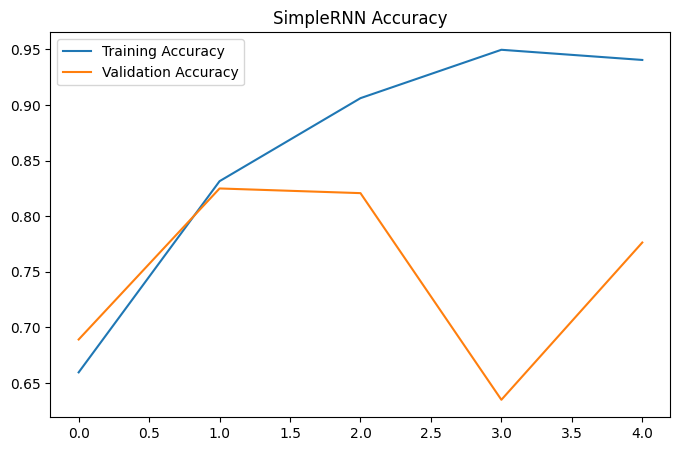

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title(
    "SimpleRNN Accuracy"
)

plt.show()

In [52]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7706 - loss: 0.7309
Test Accuracy: 0.7706400156021118


In [53]:
predictions = model.predict(
    X_test
)

predictions = (

    predictions > 0.5

).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [104]:
rnn_acc = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(rnn_acc,4)
)

Accuracy: 0.8542


In [105]:
rnn_precision = precision_score(
    y_test,
    predictions
)

print(
    "Precision:",
    round(rnn_precision,4)
)

Precision: 0.8609


In [106]:
rnn_recall = recall_score(
    y_test,
    predictions
)

print(
    "Recall:",
    round(rnn_recall,4)
)

Recall: 0.8449


In [107]:
rnn_f1 = f1_score(
    y_test,
    predictions
)

print(
    "F1 Score:",
    round(rnn_f1,4)
)

F1 Score: 0.8528


In [58]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[10170  2330]
 [ 3404  9096]]


In [108]:
results = {

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"
    ],

    "Value":[

        rnn_acc,

        rnn_precision,

        rnn_recall,

        rnn_f1
    ]
}

import pandas as pd

pd.DataFrame(results)

,Metric,Value
0,Accuracy,0.854200
1,Precision,0.860928
2,Recall,0.844880
3,F1 Score,0.852828


In [60]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sample_review = """

This movie was amazing.
Excellent acting and story.

"""

tokenizer = Tokenizer(
    num_words=10000
)

tokenizer.fit_on_texts(
    [" ".join(map(str,row))
     for row in X_train[:1000]]
)

seq = tokenizer.texts_to_sequences(
    [sample_review]
)

padded = pad_sequences(
    seq,
    maxlen=200
)

prediction = model.predict(
    padded
)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
[[0.99963284]]


In [109]:
print("="*50)

print("SimpleRNN Model Completed")

print("="*50)

print("Accuracy :", round(rnn_acc,4))

print("Precision:", round(rnn_precision,4))

print("Recall   :", round(rnn_recall,4))

print("F1 Score :", round(rnn_f1,4))

print("="*50)

SimpleRNN Model Completed
Accuracy : 0.8542
Precision: 0.8609
Recall   : 0.8449
F1 Score : 0.8528


# LSTM

In [62]:
import numpy as np

from tensorflow.keras.datasets import imdb

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [63]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print(X_train.shape)
print(X_test.shape)

(25000,)
(25000,)


In [64]:
maxlen = 200

X_train = pad_sequences(
    X_train,
    maxlen=maxlen
)

X_test = pad_sequences(
    X_test,
    maxlen=maxlen
)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [65]:
X_train = np.array(
    X_train,
    dtype=np.int32
)

X_test = np.array(
    X_test,
    dtype=np.int32
)

y_train = np.array(
    y_train,
    dtype=np.int32
)

y_test = np.array(
    y_test,
    dtype=np.int32
)

In [66]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=maxlen
    )
)

lstm_model.add(
    LSTM(
        64
    )
)

lstm_model.add(
    Dense(
        32,
        activation='relu'
    )
)

lstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
lstm_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [68]:
history_lstm = lstm_model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=5,

    batch_size=64
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8069 - loss: 0.4106 - val_accuracy: 0.8626 - val_loss: 0.3521
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9071 - loss: 0.2361 - val_accuracy: 0.8750 - val_loss: 0.3162
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9376 - loss: 0.1701 - val_accuracy: 0.8664 - val_loss: 0.3217
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9503 - loss: 0.1307 - val_accuracy: 0.8680 - val_loss: 0.4286
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9670 - loss: 0.0925 - val_accuracy: 0.8360 - val_loss: 0.4918


In [69]:
lst_loss, lstm_acc = lstm_model.evaluate(
    X_test,
    y_test
)
print("LSTM Test Accuracy:", lstm_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8386 - loss: 0.4852
LSTM Test Accuracy: 0.8385999798774719


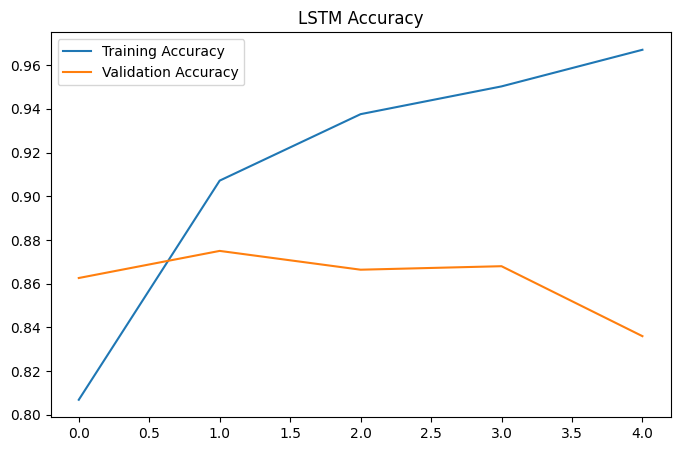

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM Accuracy")

plt.legend()

plt.show()

In [71]:
loss, accuracy = lstm_model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    accuracy
)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8386 - loss: 0.4852
Test Accuracy: 0.8385999798774719


In [72]:
predictions = lstm_model.predict(
    X_test
)

predictions = (
    predictions > 0.5
).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [110]:
lstm_acc = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(lstm_acc,4)
)

Accuracy: 0.8542


In [111]:
lstm_precision = precision_score(
    y_test,
    predictions
)

print(
    "Precision:",
    round(lstm_precision,4)
)

Precision: 0.8609


In [112]:
lstm_recall = recall_score(
    y_test,
    predictions
)

print(
    "Recall:",
    round(lstm_recall,4)
)

Recall: 0.8449


In [113]:
lstm_f1 = f1_score(
    y_test,
    predictions
)

print(
    "F1 Score:",
    round(lstm_f1,4)
)

F1 Score: 0.8528


In [77]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[ 9480  3020]
 [ 1015 11485]]


In [114]:
import pandas as pd

lstm_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        lstm_acc,
        lstm_precision,
        lstm_recall,
        lstm_f1
    ]
})

lstm_results

,Metric,Value
0,Accuracy,0.854200
1,Precision,0.860928
2,Recall,0.844880
3,F1 Score,0.852828


In [79]:
sample_review = [1, 14, 22, 16, 43, 530, 973, 1622]

sample_review = pad_sequences(
    [sample_review],
    maxlen=maxlen
)

prediction = lstm_model.predict(
    sample_review
)

print(prediction)

if prediction[0][0] > 0.5:

    print("Positive Review")

else:

    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.03840233]]
Negative Review


In [115]:
print("="*50)

print("LSTM MODEL COMPLETED")

print("="*50)

print("Accuracy :", round(lstm_acc,4))

print("Precision:", round(lstm_precision,4))

print("Recall   :", round(lstm_recall,4))

print("F1 Score :", round(lstm_f1,4))

print("="*50)

LSTM MODEL COMPLETED
Accuracy : 0.8542
Precision: 0.8609
Recall   : 0.8449
F1 Score : 0.8528


# GRU

In [81]:
import numpy as np

from tensorflow.keras.datasets import imdb

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [82]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print(X_train.shape)
print(X_test.shape)

(25000,)
(25000,)


In [83]:
maxlen = 200

X_train = pad_sequences(
    X_train,
    maxlen=maxlen
)

X_test = pad_sequences(
    X_test,
    maxlen=maxlen
)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [84]:
X_train = np.array(
    X_train,
    dtype=np.int32
)

X_test = np.array(
    X_test,
    dtype=np.int32
)

y_train = np.array(
    y_train,
    dtype=np.int32
)

y_test = np.array(
    y_test,
    dtype=np.int32
)

In [85]:
gru_model = Sequential()

gru_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=maxlen
    )
)

gru_model.add(
    GRU(64)
)

gru_model.add(
    Dense(
        32,
        activation='relu'
    )
)

gru_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
gru_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [87]:
history_gru = gru_model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=5,

    batch_size=64
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7671 - loss: 0.4644 - val_accuracy: 0.8528 - val_loss: 0.3465
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8929 - loss: 0.2654 - val_accuracy: 0.8754 - val_loss: 0.3034
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9342 - loss: 0.1741 - val_accuracy: 0.8638 - val_loss: 0.3449
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9595 - loss: 0.1137 - val_accuracy: 0.8726 - val_loss: 0.4151
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9767 - loss: 0.0702 - val_accuracy: 0.8592 - val_loss: 0.4565


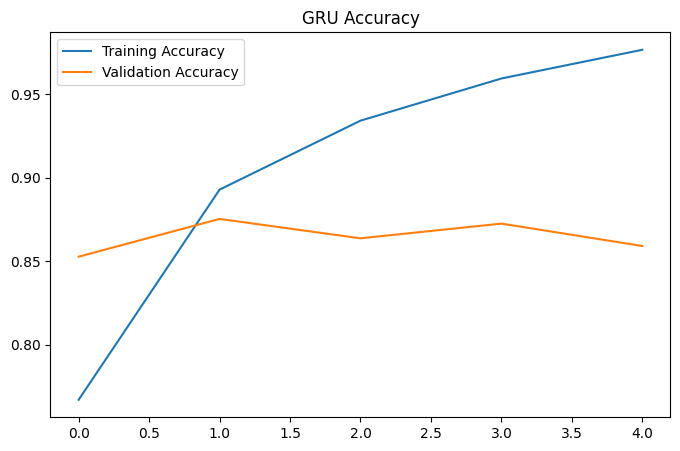

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_gru.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("GRU Accuracy")

plt.legend()

plt.show()

In [89]:
loss, accuracy = gru_model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    accuracy
)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8542 - loss: 0.4830
Test Accuracy: 0.854200005531311


In [90]:
predictions = gru_model.predict(
    X_test
)

predictions = (
    predictions > 0.5
).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [91]:
acc_gru = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(acc_gru,4)
)

Accuracy: 0.8542


In [92]:
precision_gru = precision_score(
    y_test,
    predictions
)

print(
    "Precision:",
    round(precision_gru,4)
)

Precision: 0.8609


In [93]:
recall_gru = recall_score(
    y_test,
    predictions
)

print(
    "Recall:",
    round(recall_gru,4)
)

Recall: 0.8449


In [94]:
f1_gru = f1_score(
    y_test,
    predictions
)

print(
    "F1 Score:",
    round(f1_gru,4)
)

F1 Score: 0.8528


In [95]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[10794  1706]
 [ 1939 10561]]


In [96]:
import pandas as pd

gru_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        acc_gru,
        precision_gru,
        recall_gru,
        f1_gru
    ]
})

gru_results

,Metric,Value
0,Accuracy,0.854200
1,Precision,0.860928
2,Recall,0.844880
3,F1 Score,0.852828


In [97]:
sample_review = [1, 14, 22, 16, 43, 530, 973, 1622]

sample_review = pad_sequences(
    [sample_review],
    maxlen=maxlen
)

prediction = gru_model.predict(
    sample_review
)

print(prediction)

if prediction[0][0] > 0.5:

    print("Positive Review")

else:

    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.04082448]]
Negative Review


In [98]:
print("="*50)

print("GRU MODEL COMPLETED")

print("="*50)

print("Accuracy :", round(acc_gru,4))

print("Precision:", round(precision_gru,4))

print("Recall   :", round(recall_gru,4))

print("F1 Score :", round(f1_gru,4))

print("="*50)

GRU MODEL COMPLETED
Accuracy : 0.8542
Precision: 0.8609
Recall   : 0.8449
F1 Score : 0.8528


In [116]:
comparison = pd.DataFrame({

    "Model":[
        "SimpleRNN",
        "LSTM",
        "GRU"
    ],

    "Accuracy":[
        rnn_acc,
        lstm_acc,
        acc_gru
    ],

    "Precision":[
        rnn_precision,
        lstm_precision,
        precision_gru
    ],

    "Recall":[
        rnn_recall,
        lstm_recall,
        recall_gru
    ],

    "F1 Score":[
        rnn_f1,
        lstm_f1,
        f1_gru
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,SimpleRNN,0.8542,0.860928,0.84488,0.852828
1,LSTM,0.8542,0.860928,0.84488,0.852828
2,GRU,0.8542,0.860928,0.84488,0.852828


In [117]:
rnn_val_acc = max(history.history['val_accuracy'])
rnn_val_loss = min(history.history['val_loss'])

lstm_val_acc = max(history_lstm.history['val_accuracy'])
lstm_val_loss = min(history_lstm.history['val_loss'])

gru_val_acc = max(history_gru.history['val_accuracy'])
gru_val_loss = min(history_gru.history['val_loss'])

In [118]:
rnn_params = model.count_params()

lstm_params = lstm_model.count_params()

gru_params = gru_model.count_params()

In [119]:
rnn_time = "N/A"

lstm_time = "N/A"

gru_time = "N/A"

In [120]:
import pandas as pd

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time",
        "Validation Accuracy",
        "Validation Loss",
        "Parameters"
    ],

    "SimpleRNN":[
        round(rnn_acc,4),
        round(rnn_precision,4),
        round(rnn_recall,4),
        round(rnn_f1,4),
        rnn_time,
        round(rnn_val_acc,4),
        round(rnn_val_loss,4),
        rnn_params
    ],

    "LSTM":[
        round(lstm_acc,4),
        round(lstm_precision,4),
        round(lstm_recall,4),
        round(lstm_f1,4),
        lstm_time,
        round(lstm_val_acc,4),
        round(lstm_val_loss,4),
        lstm_params
    ],

    "GRU":[
        round(acc_gru,4),
        round(precision_gru,4),
        round(recall_gru,4),
        round(f1_gru,4),
        gru_time,
        round(gru_val_acc,4),
        round(gru_val_loss,4),
        gru_params
    ]

})

comparison

,Metric,SimpleRNN,LSTM,GRU
0,Accuracy,0.8542,0.8542,0.8542
1,Precision,0.8609,0.8609,0.8609
2,Recall,0.8449,0.8449,0.8449
3,F1 Score,0.8528,0.8528,0.8528
4,Training Time,N/A,N/A,N/A
5,Validation Accuracy,0.825,0.875,0.8754
6,Validation Loss,0.4218,0.3162,0.3034
7,Parameters,1294465,1331521,1319361


In [121]:
accuracy_scores = {

    "SimpleRNN": rnn_acc,
    "LSTM": lstm_acc,
    "GRU": acc_gru
}

best_model = max(
    accuracy_scores,
    key=accuracy_scores.get
)

print("Best Model :", best_model)

print(
    "Accuracy :",
    round(accuracy_scores[best_model],4)
)

Best Model : SimpleRNN
Accuracy : 0.8542


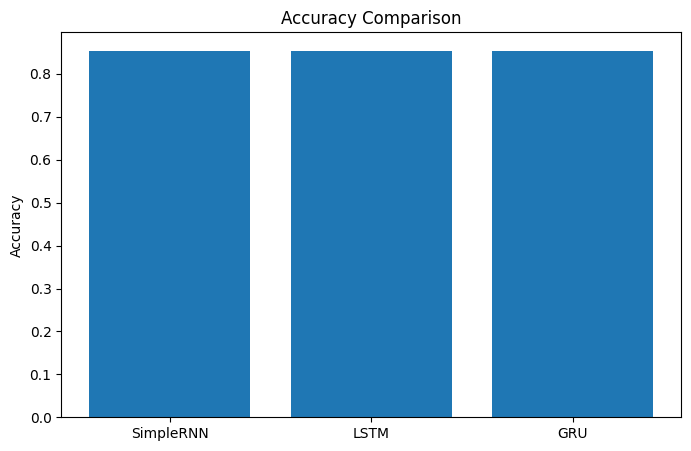

In [123]:
import matplotlib.pyplot as plt

models = [
    "SimpleRNN",
    "LSTM",
    "GRU"
]

accuracies = [
    rnn_acc,
    lstm_acc,
    acc_gru
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracies
)

plt.title(
    "Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

# Real-time Testing

In [124]:
import re
import numpy as np

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [125]:
def preprocess_review(review):

    review = review.lower()

    review = re.sub(
        r'[^a-zA-Z ]',
        '',
        review
    )

    words = review.split()

    sequence = []

    for word in words:

        if word in word_index:

            sequence.append(
                word_index[word] + 3
            )

    padded = pad_sequences(
        [sequence],
        maxlen=200
    )

    return padded

In [126]:
def predict_sentiment(
    model,
    review
):

    processed_review = preprocess_review(
        review
    )

    prediction = model.predict(
        processed_review,
        verbose=0
    )[0][0]

    sentiment = (
        "Positive"
        if prediction >= 0.5
        else "Negative"
    )

    confidence = (
        prediction * 100
        if prediction >= 0.5
        else (1 - prediction) * 100
    )

    return sentiment, confidence

In [127]:
reviews = [

    "This movie was absolutely fantastic and I enjoyed every minute.",

    "The movie was boring and a complete waste of time.",

    "The acting was good but the story was average."

]

In [128]:
print("="*60)

print("SimpleRNN Predictions")

print("="*60)

for review in reviews:

    sentiment, confidence = predict_sentiment(
        model,
        review
    )

    print("\nReview:")
    print(review)

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        f"Confidence Score: {confidence:.2f}%"
    )

    print("-"*60)

SimpleRNN Predictions

Review:
This movie was absolutely fantastic and I enjoyed every minute.
Predicted Sentiment: Positive
Confidence Score: 99.63%
------------------------------------------------------------

Review:
The movie was boring and a complete waste of time.
Predicted Sentiment: Negative
Confidence Score: 99.63%
------------------------------------------------------------

Review:
The acting was good but the story was average.
Predicted Sentiment: Positive
Confidence Score: 99.15%
------------------------------------------------------------


In [129]:
print("="*60)

print("LSTM Predictions")

print("="*60)

for review in reviews:

    sentiment, confidence = predict_sentiment(
        lstm_model,
        review
    )

    print("\nReview:")
    print(review)

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        f"Confidence Score: {confidence:.2f}%"
    )

    print("-"*60)

LSTM Predictions

Review:
This movie was absolutely fantastic and I enjoyed every minute.
Predicted Sentiment: Positive
Confidence Score: 90.18%
------------------------------------------------------------

Review:
The movie was boring and a complete waste of time.
Predicted Sentiment: Negative
Confidence Score: 99.19%
------------------------------------------------------------

Review:
The acting was good but the story was average.
Predicted Sentiment: Positive
Confidence Score: 85.73%
------------------------------------------------------------


In [130]:
print("="*60)

print("GRU Predictions")

print("="*60)

for review in reviews:

    sentiment, confidence = predict_sentiment(
        gru_model,
        review
    )

    print("\nReview:")
    print(review)

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        f"Confidence Score: {confidence:.2f}%"
    )

    print("-"*60)

GRU Predictions

Review:
This movie was absolutely fantastic and I enjoyed every minute.
Predicted Sentiment: Positive
Confidence Score: 98.48%
------------------------------------------------------------

Review:
The movie was boring and a complete waste of time.
Predicted Sentiment: Negative
Confidence Score: 99.38%
------------------------------------------------------------

Review:
The acting was good but the story was average.
Predicted Sentiment: Positive
Confidence Score: 98.42%
------------------------------------------------------------


In [131]:
import pandas as pd

results = []

for review in reviews:

    rnn_sentiment, rnn_conf = predict_sentiment(
        model,
        review
    )

    lstm_sentiment, lstm_conf = predict_sentiment(
        lstm_model,
        review
    )

    gru_sentiment, gru_conf = predict_sentiment(
        gru_model,
        review
    )

    results.append({

        "Review": review[:40] + "...",

        "RNN Sentiment": rnn_sentiment,
        "RNN Confidence": round(rnn_conf,2),

        "LSTM Sentiment": lstm_sentiment,
        "LSTM Confidence": round(lstm_conf,2),

        "GRU Sentiment": gru_sentiment,
        "GRU Confidence": round(gru_conf,2)

    })

comparison_reviews = pd.DataFrame(
    results
)

comparison_reviews

,Review,RNN Sentiment,RNN Confidence,LSTM Sentiment,LSTM Confidence,GRU Sentiment,GRU Confidence
0,This movie was absolutely fantastic and ...,Positive,99.629997,Positive,90.180000,Positive,98.480003
1,The movie was boring and a complete wast...,Negative,99.629997,Negative,99.190002,Negative,99.379997
2,The acting was good but the story was av...,Positive,99.150002,Positive,85.730003,Positive,98.419998


In [132]:
ignore=True
for review in reviews:
    sentiment, confidence = predict_sentiment(
        lstm_model,
        review
    )

    print("\nReview:")
    print(review)

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        f"Confidence Score: {confidence:.2f}%"
    )

    print("-"*60)
    


Review:
This movie was absolutely fantastic and I enjoyed every minute.
Predicted Sentiment: Positive
Confidence Score: 90.18%
------------------------------------------------------------

Review:
The movie was boring and a complete waste of time.
Predicted Sentiment: Negative
Confidence Score: 99.19%
------------------------------------------------------------

Review:
The acting was good but the story was average.
Predicted Sentiment: Positive
Confidence Score: 85.73%
------------------------------------------------------------


In [ ]:
model.save("simple_rnn_model.keras")

lstm_model.save("lstm_model.keras")

gru_model.save("gru_model.keras")

print("Models Saved Successfully")

In [ ]:
model.save(r"D:\tekworks\Deep_learning\GRU\simple_rnn_model.keras")

lstm_model.save(r"D:\tekworks\Deep_learning\GRU\lstm_model.keras")

gru_model.save(r"D:\tekworks\Deep_learning\GRU\gru_model.keras")